In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/credit-risk-dataset/credit_risk_dataset.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("/kaggle/input/credit-risk-dataset/credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
#Get a general look of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
# Let's see missing values
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [6]:
#Take a look at the statistic values for dataset
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [7]:
#Let's divide columns into two as numerical and categorical 
numerical_cols = df.select_dtypes(include = ["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include = ["object"]).columns

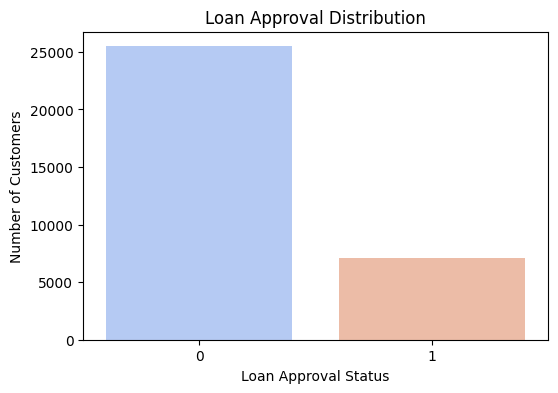

In [8]:
# Plotting the distribution of loan approval status
plt.figure(figsize=(6,4))
sns.countplot(x="loan_status", data=df, palette="coolwarm")
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approval Status")
plt.ylabel("Number of Customers")
plt.show()

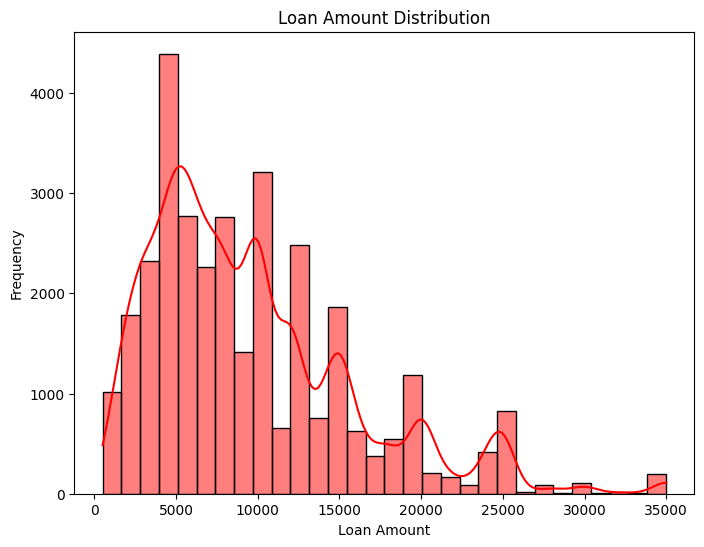

In [9]:
# Histogram for a numerical column like 'LoanAmount'
plt.figure(figsize=(8,6))
sns.histplot(df['loan_amnt'], bins=30, kde=True, color="red")
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()


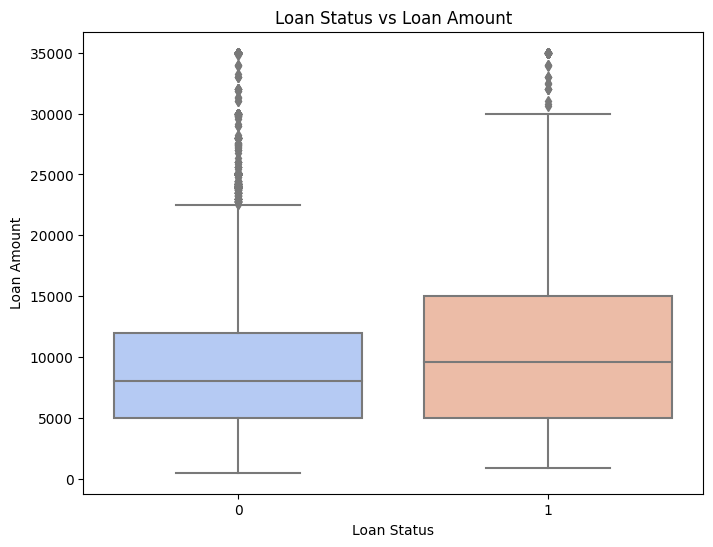

In [10]:
# Boxplot for Loan Status vs Loan Amount

plt.figure(figsize=(8,6))
sns.boxplot(x="loan_status", y="loan_amnt", data=df, palette="coolwarm")
plt.title('Loan Status vs Loan Amount')
plt.xlabel('Loan Status')
plt.ylabel('Loan Amount')
plt.show()


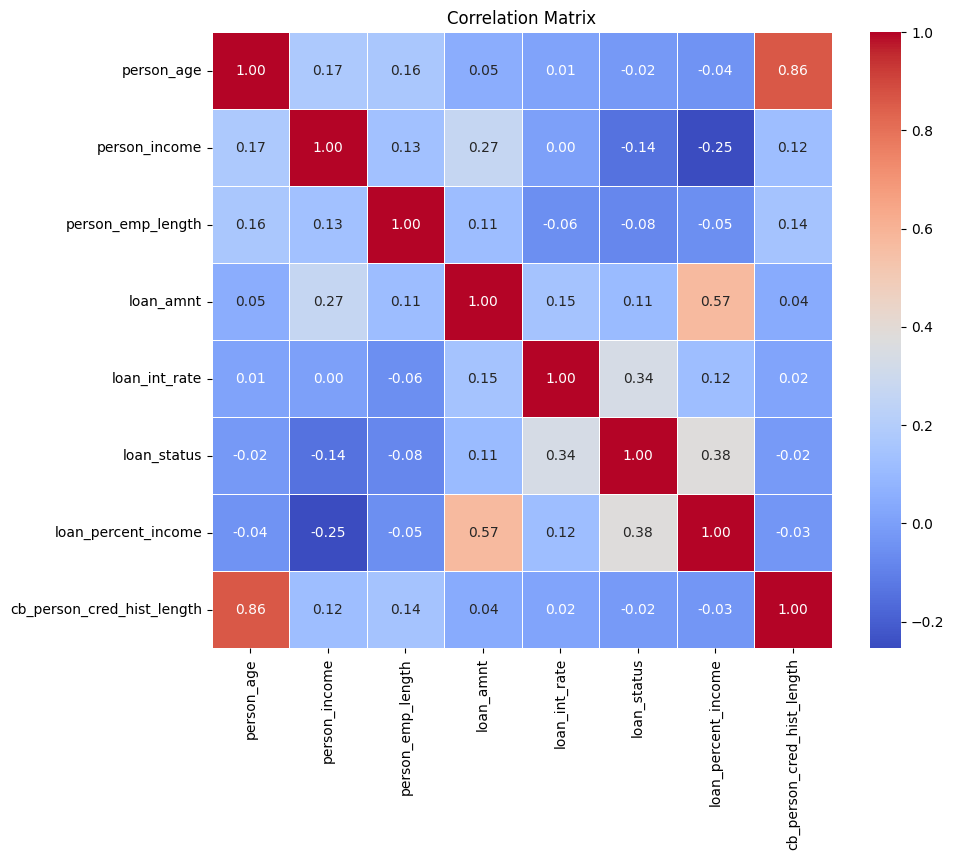

In [11]:
# Create the correlation matrix
corr_matrix = df[numerical_cols].corr()

# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


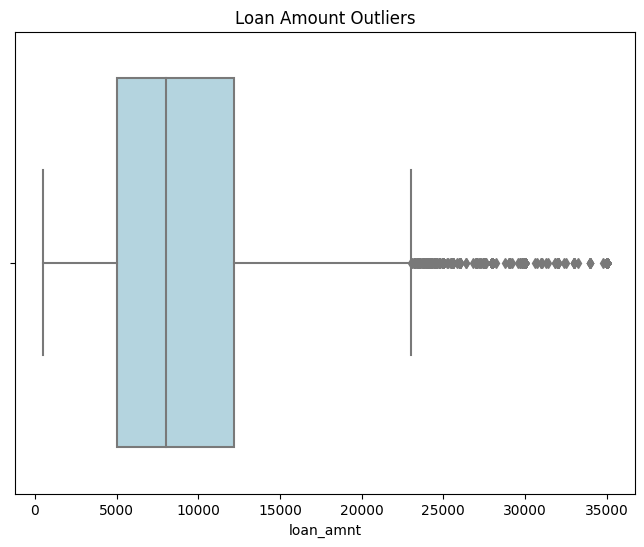

In [12]:
#Outliers in Loan Amount (Box Plot)
plt.figure(figsize=(8,6))
sns.boxplot(x=df['loan_amnt'], color='lightblue')
plt.title('Loan Amount Outliers')
plt.show()

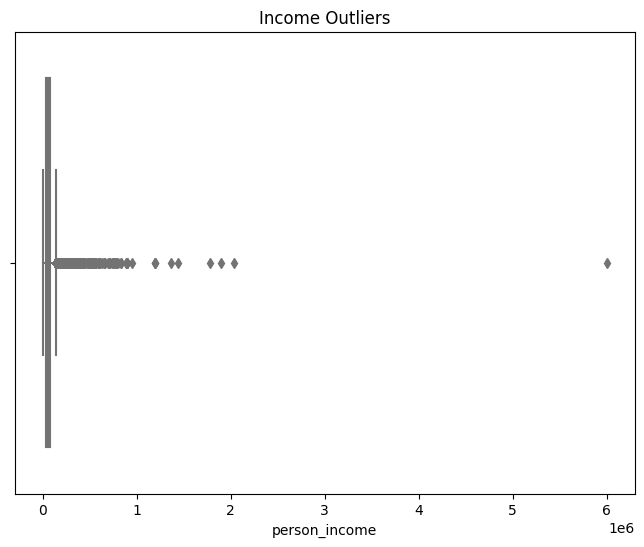

In [13]:
# Outliers in Income (Box Plot)

plt.figure(figsize=(8,6))
sns.boxplot(x=df['person_income'], color='lightgreen')
plt.title('Income Outliers')
plt.show()

EDA Report

1. Dataset Overview:
The dataset contains information about customer loan applications and their approval status. The key features in the dataset are:

Loan Amount: The amount of the loan applied for.

Income: The income of the customer applying for the loan.

Loan Approval: Whether the loan was approved or not.

2. Missing Values:
Missing values were checked for all columns.

If any missing values exist, they should be handled either by imputation or removal, depending on the context of the feature.

3. Categorical Variables Distribution:
Loan Approval: The distribution of loan approval status shows the proportion of loan applications that were approved vs. those that were rejected. This gives us an idea of how many customers are likely to be approved for loans.

4. Numerical Variables Distribution:
Loan Amount: The distribution of loan amounts shows how much customers typically apply for. There might be some outliers indicating unusually high loan requests.

Income: The income distribution provides insights into the average income levels of applicants, helping us understand the financial capacity of applicants.

5. Relationship Between Loan Approval and Numerical Features:
Loan Amount vs. Loan Approval: Using box plots, we explored how loan amounts vary for approved and rejected loans. This helps us understand whether loan amount plays a significant role in the approval process.

Income vs. Loan Approval: Similarly, we explored how income affects the likelihood of loan approval.

6. Correlation Analysis:
The correlation matrix was calculated to assess the relationships between numerical features.

Loan Amount and Income showed a positive correlation, meaning that as income increases, the loan amount also tends to increase. This could suggest that customers with higher income are more likely to request larger loans.

7. Outliers:
A box plot was used to detect potential outliers in the Loan Amount and Income features.

Outliers were observed in both features, indicating some customers either apply for very large loans or have unusually high incomes. These outliers should be further examined or handled appropriately before model building.

Conclusion:
The Loan Approval Distribution shows the balance between approved and rejected loans.

There is a positive correlation between income and loan amount, suggesting that customers with higher income tend to apply for larger loans.

Outliers in the dataset should be addressed before any predictive modeling, as they can significantly affect model performance.

Based on the EDA, the next steps would involve handling missing values, dealing with outliers, and possibly feature engineering to improve model accuracy.